<a href="https://colab.research.google.com/github/JavarBS/starbucks-customer-loyalty-analytics/blob/main/customer_behavior_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project: Starbucks Customer Loyalty & Behavior Analysis
## Author: Javar Brown-Scott
## Date: November 2024
### Objective: Analyze customer behavior patterns, loyalty program effectiveness, and provide actionable insights for marketing optimization

In [2]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
plt.style.use('fivethirtyeight')
sns.set_palette("husl")

# For Google Colab
from google.colab import drive
drive.mount('/content/drive')

# Configuration
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

Mounted at /content/drive


In [3]:
# Load the three datasets
# Update these paths based on where you saved the files in Google Drive
portfolio = pd.read_json('portfolio.json', orient='records', lines=True)
profile = pd.read_json('profile.json', orient='records', lines=True)
transcript = pd.read_json('transcript.json', orient='records', lines=True)

# Quick exploration
print("PORTFOLIO - Offer Details")
print(f"Shape: {portfolio.shape}")
print(portfolio.head())
print("\n" + "="*50 + "\n")

print("PROFILE - Customer Demographics")
print(f"Shape: {profile.shape}")
print(profile.head())
print("\n" + "="*50 + "\n")

print("TRANSCRIPT - Transaction & Offer Events")
print(f"Shape: {transcript.shape}")
print(transcript.head())

PORTFOLIO - Offer Details
Shape: (10, 6)
   reward                      channels  difficulty  duration     offer_type  \
0      10       [email, mobile, social]          10         7           bogo   
1      10  [web, email, mobile, social]          10         5           bogo   
2       0          [web, email, mobile]           0         4  informational   
3       5          [web, email, mobile]           5         7           bogo   
4       5                  [web, email]          20        10       discount   

                                 id  
0  ae264e3637204a6fb9bb56bc8210ddfd  
1  4d5c57ea9a6940dd891ad53e9dbe8da0  
2  3f207df678b143eea3cee63160fa8bed  
3  9b98b8c7a33c4b65b9aebfe6a799e6d9  
4  0b1e1539f2cc45b7b9fa7c272da2e1d7  


PROFILE - Customer Demographics
Shape: (17000, 5)
  gender  age                                id  became_member_on    income
0   None  118  68be06ca386d4c31939f3a4f0e3dd783          20170212       NaN
1      F   55  0610b486422d4921ae7d2bf64640c50

In [4]:
# Clean profile data
profile['became_member_on'] = pd.to_datetime(profile['became_member_on'], format='%Y%m%d')
profile['membership_days'] = (pd.Timestamp('2018-12-31') - profile['became_member_on']).dt.days


In [5]:
# Handle missing demographics
profile['age'].fillna(profile['age'].median(), inplace=True)
profile['income'].fillna(profile['income'].median(), inplace=True)

In [6]:
# Create age groups for segmentation
profile['age_group'] = pd.cut(profile['age'],
                              bins=[0, 25, 35, 45, 55, 65, 100],
                              labels=['Gen Z', 'Young Millennials', 'Older Millennials',
                                     'Gen X', 'Young Boomers', 'Older Boomers'])

In [7]:
# Income segments
profile['income_segment'] = pd.cut(profile['income'],
                                   bins=[0, 40000, 60000, 80000, 100000, 200000],
                                   labels=['Low', 'Lower-Middle', 'Middle', 'Upper-Middle', 'High'])

print("Customer Demographics Overview:")
print(profile.describe())

Customer Demographics Overview:
                age               became_member_on         income  \
count  17000.000000                          17000   17000.000000   
mean      62.531412  2017-02-23 13:12:10.164706048   65225.235294   
min       18.000000            2013-07-29 00:00:00   30000.000000   
25%       45.000000            2016-05-26 00:00:00   51000.000000   
50%       58.000000            2017-08-02 00:00:00   64000.000000   
75%       73.000000            2017-12-30 00:00:00   76000.000000   
max      118.000000            2018-07-26 00:00:00  120000.000000   
std       26.738580                            NaN   20174.747749   

       membership_days  
count     17000.000000  
mean        675.449882  
min         158.000000  
25%         366.000000  
50%         516.000000  
75%         949.000000  
max        1981.000000  
std         411.223904  


In [8]:
# Extract transaction data
transcript['value'] = transcript['value'].apply(lambda x: x if pd.isna(x) else eval(str(x)))

# Separate different event types
transactions = transcript[transcript['event'] == 'transaction'].copy()
offers_received = transcript[transcript['event'] == 'offer received'].copy()
offers_viewed = transcript[transcript['event'] == 'offer viewed'].copy()
offers_completed = transcript[transcript['event'] == 'offer completed'].copy()


In [9]:
# Extract amount from transactions
transactions['amount'] = transactions['value'].apply(lambda x: x.get('amount', 0) if isinstance(x, dict) else 0)


In [10]:
# Calculate customer-level metrics
customer_summary = transactions.groupby('person').agg({
    'amount': ['sum', 'mean', 'count'],
    'time': ['min', 'max']
}).round(2)

customer_summary.columns = ['total_spent', 'avg_transaction', 'num_transactions', 'first_purchase', 'last_purchase']
customer_summary['recency'] = customer_summary['last_purchase'].max() - customer_summary['last_purchase']
customer_summary.reset_index(inplace=True)

In [11]:
# Merge with profile data
customer_analytics = pd.merge(customer_summary, profile, left_on='person', right_on='id', how='inner')

print("Customer Analytics Summary Created!")
print(f"Total Customers Analyzed: {len(customer_analytics)}")
print(f"Average Customer Value: ${customer_analytics['total_spent'].mean():.2f}")

Customer Analytics Summary Created!
Total Customers Analyzed: 16578
Average Customer Value: $107.10


In [14]:
# RFM Analysis
def calculate_rfm(df):
    """Calculate RFM scores and segment customers"""

    # Calculate RFM metrics
    rfm = df[['person', 'recency', 'num_transactions', 'total_spent']].copy()
    rfm.columns = ['customer_id', 'Recency', 'Frequency', 'Monetary']

    # Create RFM scores (1-5, where 5 is best)
    rfm['R_Score'] = pd.qcut(rfm['Recency'], 5, labels=[5, 4, 3, 2, 1])
    rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 5, labels=[1, 2, 3, 4, 5])
    rfm['M_Score'] = pd.qcut(rfm['Monetary'], 5, labels=[1, 2, 3, 4, 5])

    # Combine scores
    rfm['RFM_Score'] = rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str) + rfm['M_Score'].astype(str)

    # Create segments
    def segment_customers(row):
        if row['RFM_Score'] in ['555', '554', '544', '545', '454', '455', '445']:
            return 'Champions'
        elif row['RFM_Score'] in ['543', '444', '435', '355', '354', '345', '344', '335']:
            return 'Loyal Customers'
        elif row['RFM_Score'] in ['553', '551', '552', '541', '542', '533', '532', '531', '452', '451']:
            return 'Potential Loyalists'
        elif row['RFM_Score'] in ['512', '511', '422', '421', '412', '411', '311']:
            return 'New Customers'
        elif row['RFM_Score'] in ['525', '524', '523', '522', '521', '515', '514', '513', '425', '424', '413', '414', '415', '315', '314', '313']:
            return 'Promising'
        elif row['RFM_Score'] in ['535', '534', '443', '434', '343', '334', '325', '324']:
            return 'Need Attention'
        elif row['RFM_Score'] in ['155', '154', '144', '214', '215', '115', '114']:
            return 'Cannot Lose Them'
        elif row['RFM_Score'] in ['332', '322', '231', '241', '251', '233', '232', '223', '222', '132', '123', '122', '212', '211']:
            return 'Hibernating'
        elif row['RFM_Score'] in ['111', '112', '121', '131', '141', '151']:
            return 'Lost'
        else:
            return 'About to Sleep'

    rfm['Segment'] = rfm.apply(segment_customers, axis=1)
    return rfm

In [15]:
# Apply RFM segmentation
rfm_analysis = calculate_rfm(customer_analytics)
customer_analytics = pd.merge(customer_analytics,
                              rfm_analysis[['customer_id', 'R_Score', 'F_Score', 'M_Score', 'Segment']],
                              left_on='person',
                              right_on='customer_id',
                              how='left')

In [16]:
# Segment summary
segment_summary = customer_analytics.groupby('Segment').agg({
    'total_spent': ['mean', 'sum'],
    'num_transactions': 'mean',
    'person': 'count',
    'income': 'mean',
    'age': 'mean'
}).round(2)

print("Customer Segmentation Complete!")
print("\nSegment Distribution:")
print(customer_analytics['Segment'].value_counts())
print("\nSegment Value Analysis:")
print(segment_summary)

Customer Segmentation Complete!

Segment Distribution:
Segment
About to Sleep         5467
Champions              1986
Hibernating            1767
Lost                   1375
Loyal Customers        1321
Potential Loyalists    1310
Promising              1136
Need Attention         1044
New Customers           970
Cannot Lose Them        202
Name: count, dtype: int64

Segment Value Analysis:
                    total_spent            num_transactions person    income  \
                           mean        sum             mean  count      mean   
Segment                                                                        
About to Sleep            99.53  544117.51             8.70   5467  66600.88   
Cannot Lose Them         203.39   41083.78             8.97    202  74445.54   
Champions                246.33  489212.50            13.76   1986  65264.35   
Hibernating               38.22   67527.62             5.27   1767  59290.32   
Lost                      15.72   21612.55    

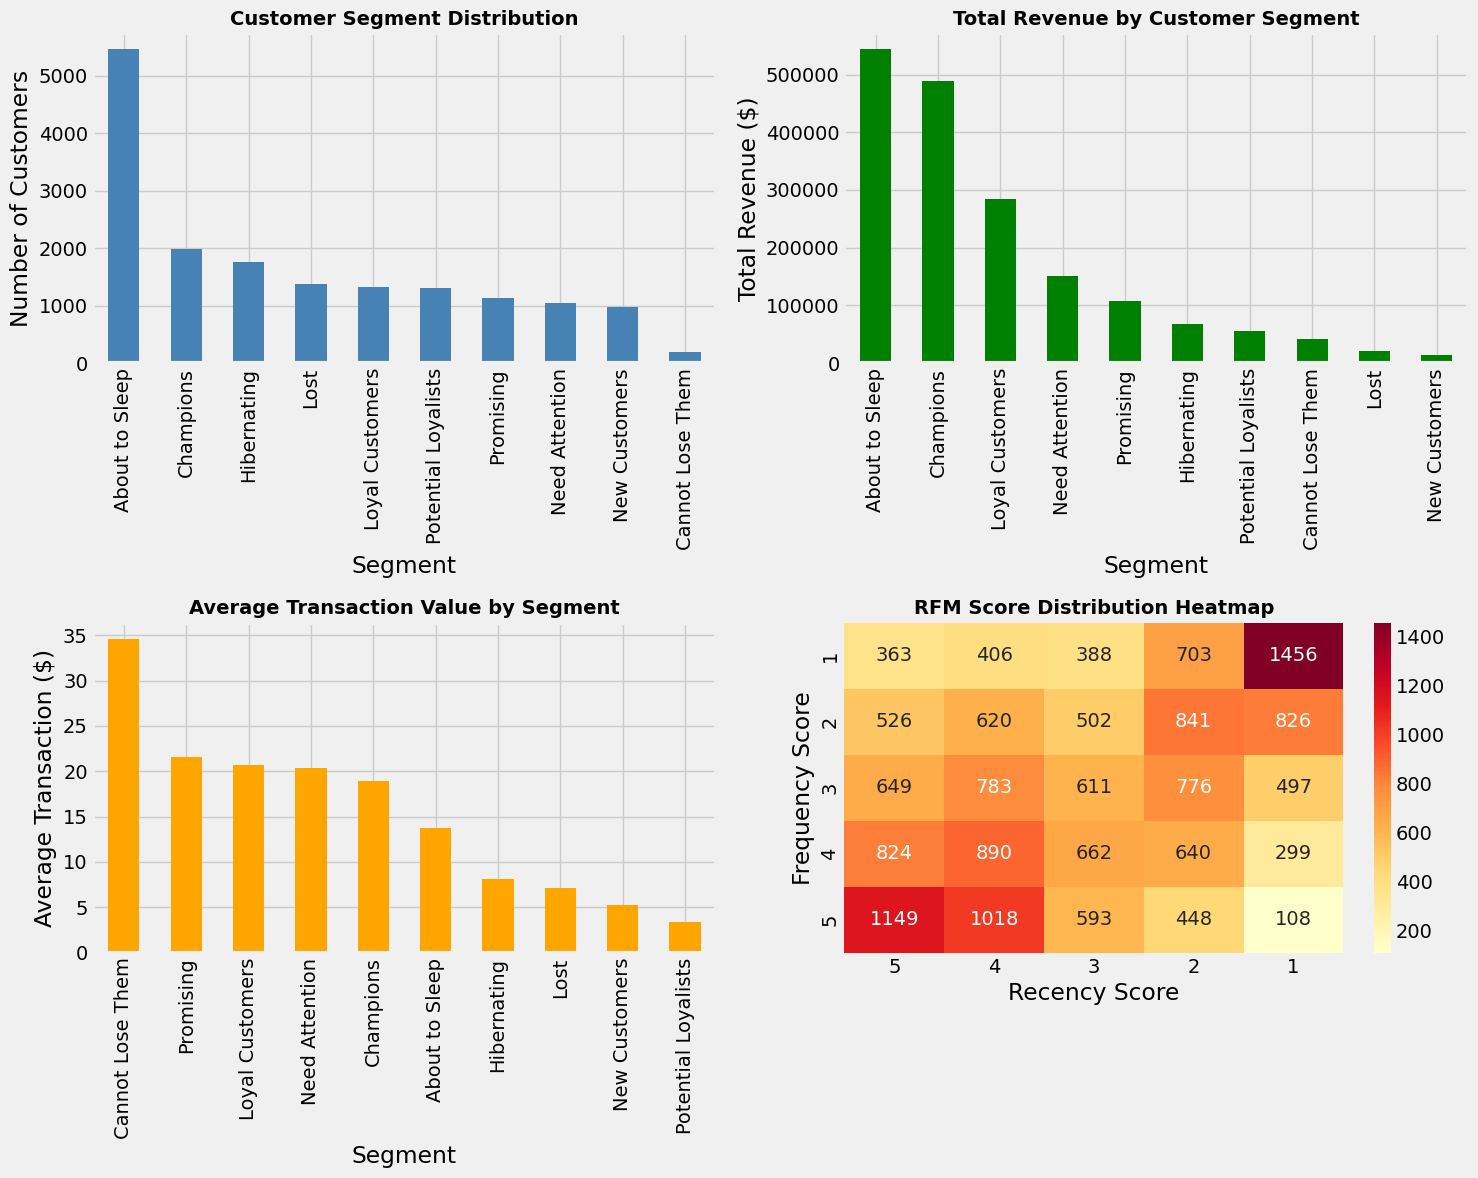

In [17]:
# 1. Customer Segment Value Matrix
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Segment distribution
customer_analytics['Segment'].value_counts().plot(kind='bar', ax=axes[0, 0], color='steelblue')
axes[0, 0].set_title('Customer Segment Distribution', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Segment')
axes[0, 0].set_ylabel('Number of Customers')

# Revenue by segment
segment_revenue = customer_analytics.groupby('Segment')['total_spent'].sum().sort_values(ascending=False)
segment_revenue.plot(kind='bar', ax=axes[0, 1], color='green')
axes[0, 1].set_title('Total Revenue by Customer Segment', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Segment')
axes[0, 1].set_ylabel('Total Revenue ($)')

# Average transaction value by segment
avg_transaction = customer_analytics.groupby('Segment')['avg_transaction'].mean().sort_values(ascending=False)
avg_transaction.plot(kind='bar', ax=axes[1, 0], color='orange')
axes[1, 0].set_title('Average Transaction Value by Segment', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Segment')
axes[1, 0].set_ylabel('Average Transaction ($)')

# RFM Score Heatmap
rfm_pivot = customer_analytics.groupby(['F_Score', 'R_Score']).size().unstack()
sns.heatmap(rfm_pivot, annot=True, fmt='d', cmap='YlOrRd', ax=axes[1, 1])
axes[1, 1].set_title('RFM Score Distribution Heatmap', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Recency Score')
axes[1, 1].set_ylabel('Frequency Score')

plt.tight_layout()
plt.show()

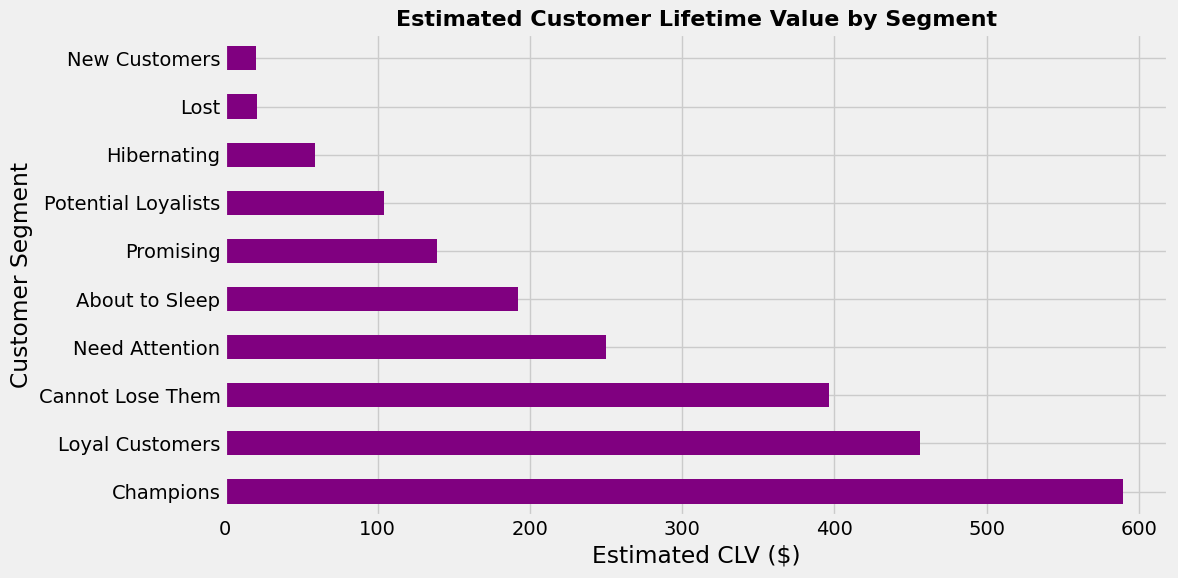

In [18]:
# 2. Customer Lifetime Value Analysis
plt.figure(figsize=(12, 6))

# Calculate simple CLV (total_spent * predicted_future_transactions)
customer_analytics['estimated_clv'] = customer_analytics['total_spent'] * (1 + customer_analytics['num_transactions']/10)

# Plot CLV by segment
clv_by_segment = customer_analytics.groupby('Segment')['estimated_clv'].mean().sort_values(ascending=False)
clv_by_segment.plot(kind='barh', color='purple')
plt.title('Estimated Customer Lifetime Value by Segment', fontsize=16, fontweight='bold')
plt.xlabel('Estimated CLV ($)')
plt.ylabel('Customer Segment')
plt.tight_layout()
plt.show()

In [24]:
# First, let's check what's in the value column for offers
print("Checking offer data structure...")
print(offers_received['value'].head())

# Extract offer_id from the value dictionary
offers_received['offer_id'] = offers_received['value'].apply(lambda x: x.get('offer id') if isinstance(x, dict) else None)
offers_viewed['offer_id'] = offers_viewed['value'].apply(lambda x: x.get('offer id') if isinstance(x, dict) else None)
offers_completed['offer_id'] = offers_completed['value'].apply(lambda x: x.get('offer_id') if isinstance(x, dict) else x.get('offer id') if isinstance(x, dict) else None)

# Check if extraction worked
print(f"Offers received with valid offer_id: {offers_received['offer_id'].notna().sum()}")
print(f"Offers completed with valid offer_id: {offers_completed['offer_id'].notna().sum()}")


Checking offer data structure...
0    {'offer id': '9b98b8c7a33c4b65b9aebfe6a799e6d9'}
1    {'offer id': '0b1e1539f2cc45b7b9fa7c272da2e1d7'}
2    {'offer id': '2906b810c7d4411798c6938adc9daaa5'}
3    {'offer id': 'fafdcd668e3743c1bb461111dcafc2a4'}
4    {'offer id': '4d5c57ea9a6940dd891ad53e9dbe8da0'}
Name: value, dtype: object
Offers received with valid offer_id: 76277
Offers completed with valid offer_id: 33579


In [25]:
# Calculate offer completion rate
# Count total offers received per offer type
offers_sent = offers_received.groupby('offer_id').size().reset_index(name='total_sent')

# Count offers completed per offer type
offers_done = offers_completed.groupby('offer_id').size().reset_index(name='total_completed')

# Merge to calculate conversion
conversion_analysis = pd.merge(offers_sent, offers_done, on='offer_id', how='left')
conversion_analysis['total_completed'].fillna(0, inplace=True)
conversion_analysis['conversion_rate'] = (conversion_analysis['total_completed'] / conversion_analysis['total_sent'] * 100).round(2)


In [26]:
# Add portfolio details
conversion_analysis = pd.merge(conversion_analysis, portfolio, left_on='offer_id', right_on='id', how='left')



Offer Performance Analysis:
      offer_type  difficulty  reward  conversion_rate
9       discount          10       2            69.99
1       discount           7       3            67.43
8           bogo           5       5            56.74
6           bogo           5       5            56.71
2       discount          10       2            52.63
7           bogo          10      10            48.16
0       discount          20       5            44.60
4           bogo          10      10            43.87
5  informational           0       0             0.00
3  informational           0       0             0.00


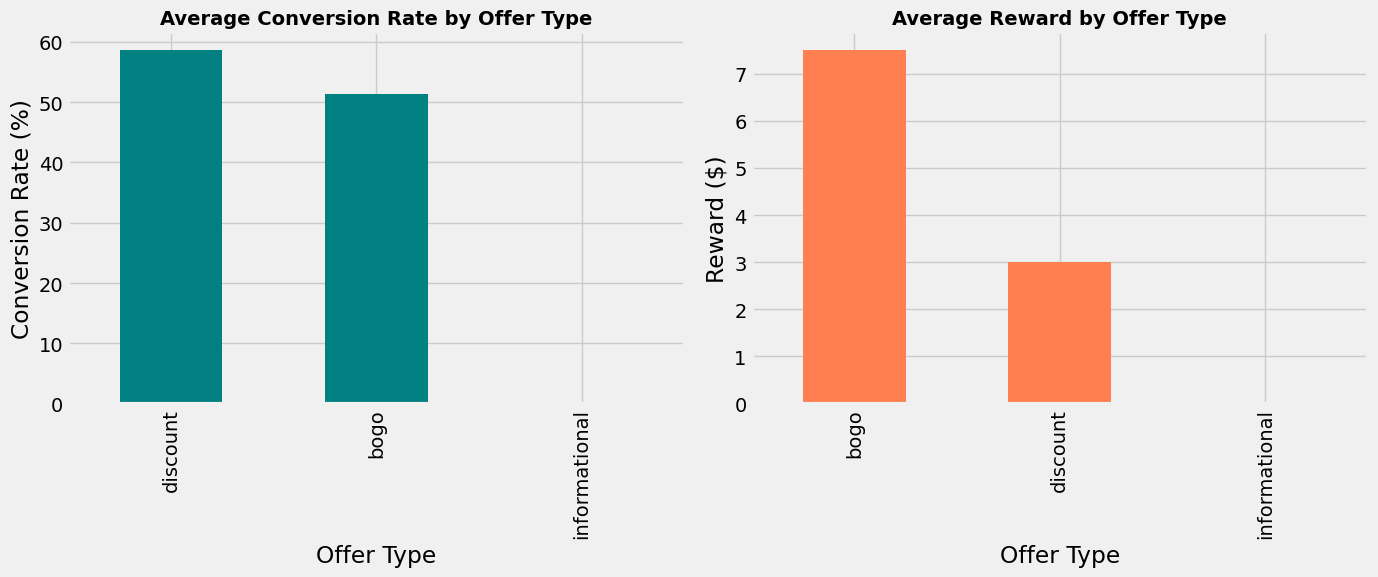

In [27]:
# Display results
print("\nOffer Performance Analysis:")
print("="*60)
if 'offer_type' in conversion_analysis.columns:
    print(conversion_analysis[['offer_type', 'difficulty', 'reward', 'conversion_rate']].sort_values('conversion_rate', ascending=False))
else:
    print(conversion_analysis[['offer_id', 'total_sent', 'total_completed', 'conversion_rate']].sort_values('conversion_rate', ascending=False))

# Alternative visualization if offer_type doesn't exist
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# If we have offer_type, use it; otherwise use offer_id
if 'offer_type' in conversion_analysis.columns:
    # Conversion by offer type
    offer_type_conv = conversion_analysis.groupby('offer_type')['conversion_rate'].mean().sort_values(ascending=False)
    offer_type_conv.plot(kind='bar', ax=axes[0], color='teal')
    axes[0].set_title('Average Conversion Rate by Offer Type', fontsize=14, fontweight='bold')
    axes[0].set_ylabel('Conversion Rate (%)')
    axes[0].set_xlabel('Offer Type')

    # Average reward by offer type
    offer_type_reward = conversion_analysis.groupby('offer_type')['reward'].mean().sort_values(ascending=False)
    offer_type_reward.plot(kind='bar', ax=axes[1], color='coral')
    axes[1].set_title('Average Reward by Offer Type', fontsize=14, fontweight='bold')
    axes[1].set_ylabel('Reward ($)')
    axes[1].set_xlabel('Offer Type')
else:
    # Top 10 performing offers
    top_offers = conversion_analysis.nlargest(10, 'conversion_rate')
    top_offers.plot(x='offer_id', y='conversion_rate', kind='bar', ax=axes[0], color='teal', legend=False)
    axes[0].set_title('Top 10 Offers by Conversion Rate', fontsize=14, fontweight='bold')
    axes[0].set_ylabel('Conversion Rate (%)')
    axes[0].set_xlabel('Offer ID')
    axes[0].tick_params(axis='x', rotation=45)

    # Total completions by offer
    top_completions = conversion_analysis.nlargest(10, 'total_completed')
    top_completions.plot(x='offer_id', y='total_completed', kind='bar', ax=axes[1], color='coral', legend=False)
    axes[1].set_title('Top 10 Offers by Total Completions', fontsize=14, fontweight='bold')
    axes[1].set_ylabel('Total Completions')
    axes[1].set_xlabel('Offer ID')
    axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [29]:
# Additional Analysis: Customer Response to Offers
print("\n" + "="*60)
print("CUSTOMER ENGAGEMENT WITH OFFERS")
print("="*60)

# How many offers does each customer complete?
customer_offer_engagement = offers_completed.groupby('person').size().reset_index(name='offers_completed')
customer_offer_received = offers_received.groupby('person').size().reset_index(name='offers_received')
customer_offer_viewed = offers_viewed.groupby('person').size().reset_index(name='offers_viewed')


CUSTOMER ENGAGEMENT WITH OFFERS


In [30]:
# Merge all offer interactions
offer_engagement = pd.merge(customer_offer_received, customer_offer_viewed, on='person', how='outer')
offer_engagement = pd.merge(offer_engagement, customer_offer_engagement, on='person', how='outer')
offer_engagement.fillna(0, inplace=True)

# Calculate engagement metrics
offer_engagement['view_rate'] = (offer_engagement['offers_viewed'] / offer_engagement['offers_received'] * 100).round(2)
offer_engagement['completion_rate'] = (offer_engagement['offers_completed'] / offer_engagement['offers_received'] * 100).round(2)

# Replace inf values with 0
offer_engagement.replace([np.inf, -np.inf], 0, inplace=True)

print(f"Average offers received per customer: {offer_engagement['offers_received'].mean():.2f}")
print(f"Average view rate: {offer_engagement['view_rate'].mean():.2f}%")
print(f"Average completion rate: {offer_engagement['completion_rate'].mean():.2f}%")

# Merge with customer analytics
customer_analytics = pd.merge(customer_analytics, offer_engagement, left_on='person', right_on='person', how='left')

# Analyze offer engagement by customer segment
segment_engagement = customer_analytics.groupby('Segment').agg({
    'offers_received': 'mean',
    'offers_viewed': 'mean',
    'offers_completed': 'mean',
    'view_rate': 'mean',
    'completion_rate': 'mean'
}).round(2)

print("\nOffer Engagement by Customer Segment:")
print(segment_engagement)

Average offers received per customer: 4.49
Average view rate: 76.04%
Average completion rate: 44.00%

Offer Engagement by Customer Segment:
                     offers_received  offers_viewed  offers_completed  \
Segment                                                                 
About to Sleep                  4.50           3.40              2.01   
Cannot Lose Them                4.40           3.41              2.59   
Champions                       4.76           3.91              3.68   
Hibernating                     4.34           3.10              1.20   
Lost                            4.36           3.11              0.44   
Loyal Customers                 4.63           3.73              3.39   
Need Attention                  4.35           3.43              2.98   
New Customers                   4.35           3.00              0.42   
Potential Loyalists             4.65           3.44              1.45   
Promising                       4.29           3.12      

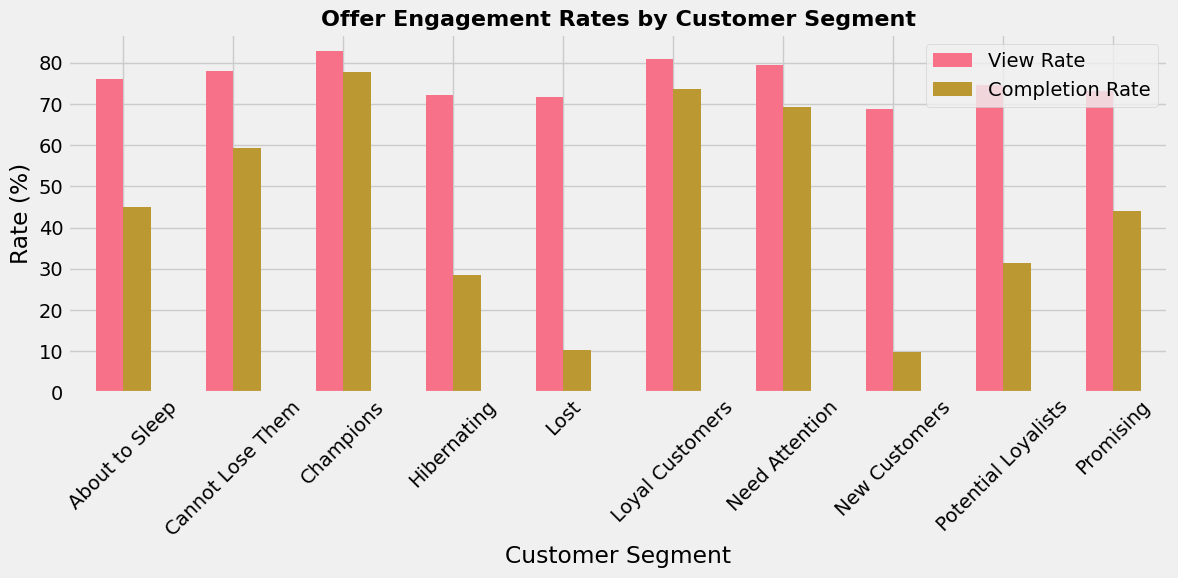

In [31]:
# Visualize engagement by segment
fig, ax = plt.subplots(figsize=(12, 6))
segment_engagement[['view_rate', 'completion_rate']].plot(kind='bar', ax=ax)
ax.set_title('Offer Engagement Rates by Customer Segment', fontsize=16, fontweight='bold')
ax.set_ylabel('Rate (%)')
ax.set_xlabel('Customer Segment')
ax.legend(['View Rate', 'Completion Rate'])
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [22]:
# Generate actionable insights
print("="*60)
print("EXECUTIVE SUMMARY: CUSTOMER BEHAVIOR & LOYALTY INSIGHTS")
print("="*60)

print("\n🎯 KEY FINDINGS:\n")

# 1. Customer Value Distribution
top_20_percent = int(len(customer_analytics) * 0.2)
top_customers_revenue = customer_analytics.nlargest(top_20_percent, 'total_spent')['total_spent'].sum()
total_revenue = customer_analytics['total_spent'].sum()
print(f"1. PARETO PRINCIPLE CONFIRMED:")
print(f"   - Top 20% of customers generate {(top_customers_revenue/total_revenue*100):.1f}% of revenue")
print(f"   - Average spent by top 20%: ${customer_analytics.nlargest(top_20_percent, 'total_spent')['total_spent'].mean():.2f}")
print(f"   - Average spent by bottom 80%: ${customer_analytics.nsmallest(int(len(customer_analytics)*0.8), 'total_spent')['total_spent'].mean():.2f}")

# 2. Segment Opportunities
print(f"\n2. SEGMENT OPPORTUNITIES:")
champions = customer_analytics[customer_analytics['Segment'] == 'Champions']
at_risk = customer_analytics[customer_analytics['Segment'].isin(['Cannot Lose Them', 'At Risk', 'About to Sleep'])]
print(f"   - Champions: {len(champions)} customers, ${champions['total_spent'].mean():.2f} avg value")
print(f"   - At-Risk High-Value: {len(at_risk)} customers worth ${at_risk['total_spent'].sum():,.2f}")
print(f"   - Potential uplift from retention: ${at_risk['total_spent'].sum() * 0.3:,.2f}")

# 3. Demographic Insights
print(f"\n3. HIGH-VALUE CUSTOMER PROFILE:")
high_value = customer_analytics[customer_analytics['total_spent'] > customer_analytics['total_spent'].quantile(0.75)]
print(f"   - Average age: {high_value['age'].mean():.0f} years")
print(f"   - Average income: ${high_value['income'].mean():,.0f}")
print(f"   - Most valuable age group: {high_value['age_group'].mode()[0] if len(high_value['age_group'].mode()) > 0 else 'N/A'}")
print(f"   - Gender split: {high_value['gender'].value_counts(normalize=True).to_dict()}")

print("\n📊 ACTIONABLE RECOMMENDATIONS:\n")
recommendations = [
    "1. IMMEDIATE ACTION: Launch retention campaign for 'Cannot Lose Them' segment",
    "2. LOYALTY OPTIMIZATION: Increase rewards for Champions to maintain engagement",
    "3. GROWTH OPPORTUNITY: Convert 'Potential Loyalists' with targeted offers",
    "4. COST SAVINGS: Reduce marketing spend on 'Lost' customers (reallocate budget)",
    "5. PERSONALIZATION: Create age-specific campaigns for highest-value demographics"
]

for rec in recommendations:
    print(f"   {rec}")

# Calculate potential impact
print("\n💰 FINANCIAL IMPACT PROJECTION:")
print(f"   - 10% increase in Champion segment: ${champions['total_spent'].sum() * 0.1:,.2f}")
print(f"   - 50% retention of at-risk customers: ${at_risk['total_spent'].sum() * 0.5:,.2f}")
print(f"   - Total potential revenue impact: ${(champions['total_spent'].sum() * 0.1 + at_risk['total_spent'].sum() * 0.5):,.2f}")

EXECUTIVE SUMMARY: CUSTOMER BEHAVIOR & LOYALTY INSIGHTS

🎯 KEY FINDINGS:

1. PARETO PRINCIPLE CONFIRMED:
   - Top 20% of customers generate 53.4% of revenue
   - Average spent by top 20%: $285.85
   - Average spent by bottom 80%: $62.41

2. SEGMENT OPPORTUNITIES:
   - Champions: 1986 customers, $246.33 avg value
   - At-Risk High-Value: 5669 customers worth $585,201.29
   - Potential uplift from retention: $175,560.39

3. HIGH-VALUE CUSTOMER PROFILE:
   - Average age: 57 years
   - Average income: $76,374
   - Most valuable age group: Older Boomers
   - Gender split: {'F': 0.5330917874396135, 'M': 0.4502415458937198, 'O': 0.016666666666666666}

📊 ACTIONABLE RECOMMENDATIONS:

   1. IMMEDIATE ACTION: Launch retention campaign for 'Cannot Lose Them' segment
   2. LOYALTY OPTIMIZATION: Increase rewards for Champions to maintain engagement
   3. GROWTH OPPORTUNITY: Convert 'Potential Loyalists' with targeted offers
   4. COST SAVINGS: Reduce marketing spend on 'Lost' customers (reallocate b